In [1]:
#necessary imports

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


# Example 1 is simple without any use of LLM...It is related to cricket..It do mathematical calculations on Batsman's data

In [ ]:
class BatsmanState(TypedDict):
    runs: int 
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summery: str



In each of below functions/Nodes we cannot return complete state as they will run in parallel and there is a state update conflict between them so we only do partial update(return only updated entity)

In [8]:
def calculate_strike_rate(state: BatsmanState):
    sr = (state['runs'] / state['balls']) * 100
    # return state
    return {"strike_rate": sr}

def calculate_balls_per_boundary(state: BatsmanState):
    total_boundaries = state['fours'] + state['sixes']
    if total_boundaries > 0:
        bpb = state['balls'] / total_boundaries
    else:
        bpb = 0
    return {"balls_per_boundary": bpb}

def calculate_boundary_percentage(state: BatsmanState):
    total_runs = state['runs']
    if total_runs > 0:
        bp = ((state['fours'] * 4) + (state['sixes'] * 6)) / total_runs * 100
    else:
        bp = 0
    return {"boundary_percentage": bp}

def summery(state: BatsmanState):

    summary = f"""
        Strike Rate = {state['strike_rate']}\n
        Balls Per Boundary = {state['balls_per_boundary']}\n
        Boundary Percentage = {state["boundary_percentage"]}
    """
    return {"summery": summary}

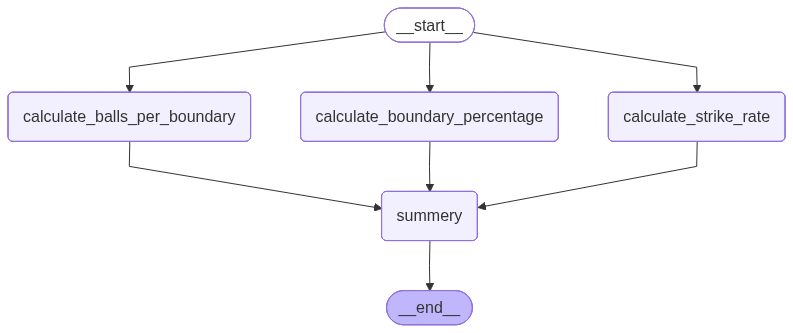

In [10]:
#making graph
batsman_graph = StateGraph(BatsmanState)

batsman_graph.add_node("calculate_strike_rate", calculate_strike_rate)
batsman_graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
batsman_graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
batsman_graph.add_node("summery" , summery)


batsman_graph.add_edge(START, "calculate_strike_rate")
batsman_graph.add_edge(START, "calculate_balls_per_boundary")
batsman_graph.add_edge(START, "calculate_boundary_percentage")
batsman_graph.add_edge("calculate_strike_rate", "summery")
batsman_graph.add_edge("calculate_balls_per_boundary", "summery")
batsman_graph.add_edge("calculate_boundary_percentage", "summery")
batsman_graph.add_edge("summery", END)


batsman_workflow = batsman_graph.compile()

batsman_workflow



In [11]:
initial_state = {
    "runs": 120,
    "balls": 100,
    "fours": 10,
    "sixes": 5
}

batsman_workflow.invoke(initial_state)

{'runs': 120,
 'balls': 100,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 120.0,
 'balls_per_boundary': 6.666666666666667,
 'boundary_percentage': 58.333333333333336,
 'summery': '\n        Strike Rate = 120.0\n\n        Balls Per Boundary = 6.666666666666667\n\n        Boundary Percentage = 58.333333333333336\n    '}

# Example 2 is a parallel workflow that uses LLMs...It analyses the given Essay on different aspects using LLMs.

In [18]:
from pydantic import BaseModel, Field
from typing import Annotated
import operator

In [13]:
load_dotenv(override=True)

#we use gpt_4o_mini as it gives structured output..

model = ChatOpenAI(
    model="gpt-4o-mini", 
    api_key=os.getenv("github_OPENAI_KEY"), 
    base_url="https://models.inference.ai.azure.com" 
)



try:
    print("Testing Updated GitHub Token...")
    print("Response:", model.invoke("Hello!").content)
except Exception as e:
    print(f"Error: {e}")

Testing Updated GitHub Token...
Response: Hello! How can I assist you today?


In [15]:
#creating a schema for the output of the LLM model
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the Essay")
    score: int = Field(description="Score out of 10 for the Essay" , ge=0, le=10) 


In [16]:
#get model that will always give structured output according to the EvaluationSchema
structured_model = model.with_structured_output(EvaluationSchema)

In [19]:
#state of workflow

class EssayState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str

    individual_scores: Annotated[list[int], operator.add]  #here we use reducer function that tell that this variable wiil be uodated by adding value to it rather than replacing it
    average_score: float

In [20]:
def evaluate_language(state: EssayState):
    prompt = f"Evaluate the language quality used in the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    response = structured_model.invoke(prompt)
    return {
        "language_feedback": response.feedback,
        "individual_scores": [response.score]  # we return a list here because we want to use operator.add to update this variable in the state
    }

In [21]:
def evaluate_analysis(state: EssayState):
    prompt = f"Evaluate the depth of analysisof the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    response = structured_model.invoke(prompt)
    return {
        "analysis_feedback": response.feedback,
        "individual_scores": [response.score]  # we return a list here because we want to use operator.add to update this variable in the state
    }

In [33]:
def evaluate_clarity(state: EssayState):
    prompt = f"Evaluate the clarity of thought of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    response = structured_model.invoke(prompt)
    return {
        "clarity_feedback": response.feedback,
        "individual_scores": [response.score]  # we return a list here because we want to use operator.add to update this variable in the state
    }

In [31]:
def final_evaluation(state: EssayState):
    prompt = f"Based on the followingfeedbacks generate a summerized feedback:\n {state['language_feedback']} \n {state['analysis_feedback']} \n {state['clarity_feedback']}"
    response = model.invoke(prompt)  # here we can use normal model as we just want to generate a summary feedback and not a structured output
    average_score = sum(state['individual_scores']) / len(state['individual_scores']) if state['individual_scores'] else 0
    return {
        "overall_feedback": response.content,
        "average_score": average_score
    }

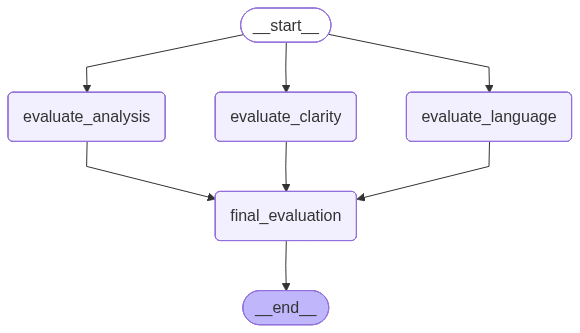

In [24]:
#making graph
essay_graph = StateGraph(EssayState)

essay_graph.add_node("evaluate_language" , evaluate_language)
essay_graph.add_node("evaluate_analysis" , evaluate_analysis)
essay_graph.add_node("evaluate_clarity" , evaluate_clarity)
essay_graph.add_node("final_evaluation" , final_evaluation)


essay_graph.add_edge(START, "evaluate_language")
essay_graph.add_edge(START, "evaluate_analysis")
essay_graph.add_edge(START, "evaluate_clarity")
essay_graph.add_edge("evaluate_language", "final_evaluation")
essay_graph.add_edge("evaluate_analysis", "final_evaluation")
essay_graph.add_edge("evaluate_clarity", "final_evaluation")
essay_graph.add_edge("final_evaluation", END)

essay_workflow = essay_graph.compile()
essay_workflow

In [25]:
sample_essay = """
AI in Cybersecurity

Artificial Intelligence (AI) plays an important role in modern cybersecurity. It helps organizations detect and prevent cyber threats more quickly and accurately than traditional security systems. Because cyberattacks are increasing in number and complexity, AI provides automated and intelligent solutions to protect networks, systems, and data.

One major use of AI in cybersecurity is threat detection. AI systems can analyze large amounts of network data and identify unusual patterns that may indicate a cyberattack, such as malware, phishing attempts, or unauthorized access. This allows security teams to respond to threats in real time.

AI is also used for automated response and prevention. When a suspicious activity is detected, AI-based systems can automatically block malicious traffic, isolate infected devices, or alert administrators. This reduces response time and limits potential damage.

Another important application is predictive analysis. AI can learn from past cyberattacks and predict possible future threats. By analyzing previous attack patterns, it helps organizations strengthen their security measures in advance.

In conclusion, AI has become a powerful tool in cybersecurity. It improves threat detection, speeds up response times, and helps organizations stay ahead of cybercriminals. As technology continues to evolve, AI will play an even greater role in protecting digital systems and sensitive information.
"""

In [27]:
bad_essay = """
AI in Cybersecurity

AI in cybersecurity is very important thing now days because many hackers doing cyber attacks on computers and networks. AI help the systems to detect bad activities and protect the data from cyber criminals. Without AI it is very difficult to handle many attacks happening on internet.

One use of AI is it can check large amount of data and find strange or unusual behaviour in the network. If some hacker trying to break the system or sending malware then AI can detect it fastly and give warning to security peoples.

Also AI can automatically stop some attacks. For example if suspicious activity found then system can block that user or stop the traffic. This help to reduce damage and keep system safe.

Another thing is AI can learn from old cyber attacks and predict future attacks. By analyzing previous attacks it make the security system more strong.

In conclusion AI is very helpful in cybersecurity because it detect attacks, protect data and make computer systems more safe from hackers.
"""

In [30]:
initial_state = {
    "essay": sample_essay
}

essay_workflow.invoke(initial_state)

c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback...der audience.', score=7), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback...nsiderations.', score=6), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:4

{'essay': '\nAI in Cybersecurity\n\nArtificial Intelligence (AI) plays an important role in modern cybersecurity. It helps organizations detect and prevent cyber threats more quickly and accurately than traditional security systems. Because cyberattacks are increasing in number and complexity, AI provides automated and intelligent solutions to protect networks, systems, and data.\n\nOne major use of AI in cybersecurity is threat detection. AI systems can analyze large amounts of network data and identify unusual patterns that may indicate a cyberattack, such as malware, phishing attempts, or unauthorized access. This allows security teams to respond to threats in real time.\n\nAI is also used for automated response and prevention. When a suspicious activity is detected, AI-based systems can automatically block malicious traffic, isolate infected devices, or alert administrators. This reduces response time and limits potential damage.\n\nAnother important application is predictive analy

In [28]:
initial_state_for_bad_essay = {
    "essay": bad_essay
}

essay_workflow.invoke(initial_state_for_bad_essay)

c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback... explanation.', score=4), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback...ore engaging.', score=5), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\mrbil\OneDrive - Higher Education Commission\LangGraph\LangGraph-Practical\myenv\Lib\site-packages\pydantic\main.py:4

{'essay': '\nAI in Cybersecurity\n\nAI in cybersecurity is very important thing now days because many hackers doing cyber attacks on computers and networks. AI help the systems to detect bad activities and protect the data from cyber criminals. Without AI it is very difficult to handle many attacks happening on internet.\n\nOne use of AI is it can check large amount of data and find strange or unusual behaviour in the network. If some hacker trying to break the system or sending malware then AI can detect it fastly and give warning to security peoples.\n\nAlso AI can automatically stop some attacks. For example if suspicious activity found then system can block that user or stop the traffic. This help to reduce damage and keep system safe.\n\nAnother thing is AI can learn from old cyber attacks and predict future attacks. By analyzing previous attacks it make the security system more strong.\n\nIn conclusion AI is very helpful in cybersecurity because it detect attacks, protect data an